In [1]:
# import libraries
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("Mall_Customers.csv")

In [3]:
df.head()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.shape

(200, 5)

In [6]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [8]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [10]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

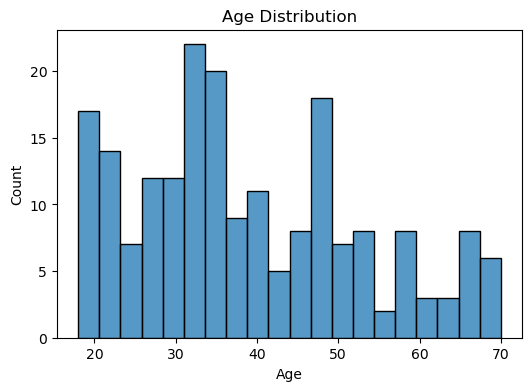

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
# Age distribution
plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=20)
plt.title("Age Distribution")
plt.show()

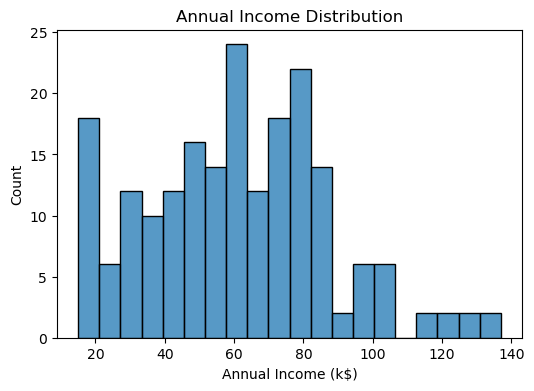

In [18]:
# Income distribution
plt.figure(figsize=(6,4))
sns.histplot(df["Annual Income (k$)"], bins=20)
plt.title("Annual Income Distribution")
plt.show()

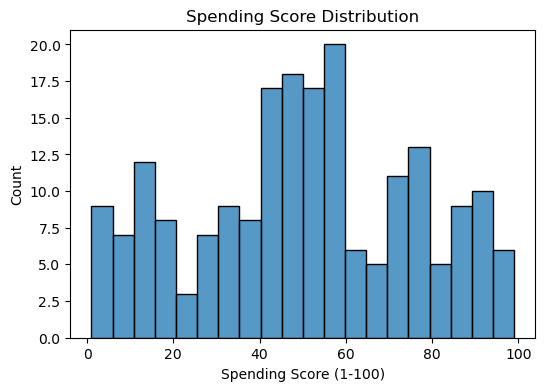

In [16]:
# Spending score 
plt.figure(figsize=(6,4))
sns.histplot(df["Spending Score (1-100)"], bins=20)
plt.title("Spending Score Distribution")
plt.show()

In [33]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [27]:
encoder = LabelEncoder()

df["Genre"] = encoder.fit_transform(df["Genre"])

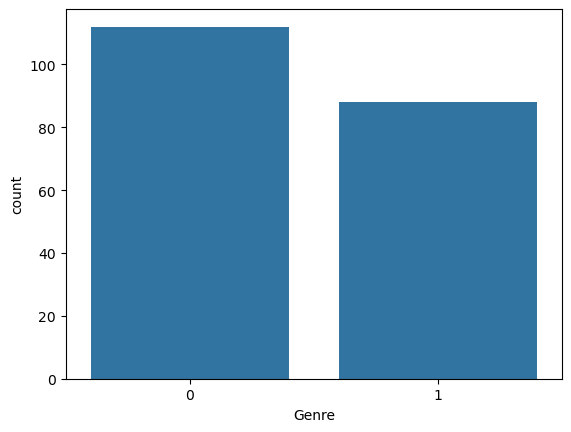

In [28]:
sns.countplot(data=df, x="Genre")
plt.show()

In [29]:
df.drop("CustomerID", axis=1, inplace=True)

In [32]:
# feature scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [34]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_data)

In [36]:
n_components = 2

In [38]:
# check explained variance
print(pca.explained_variance_ratio_)

[0.33690046 0.26230645]


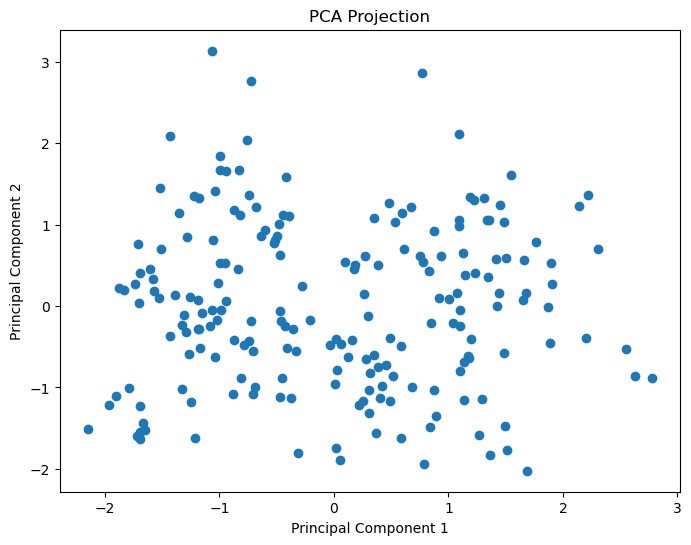

In [39]:
 # visualize PCA
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1]
)

plt.title("PCA Projection")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.show()

In [40]:
# For cluster we use Elbow method
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_pca)

    wcss.append(kmeans.inertia_)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

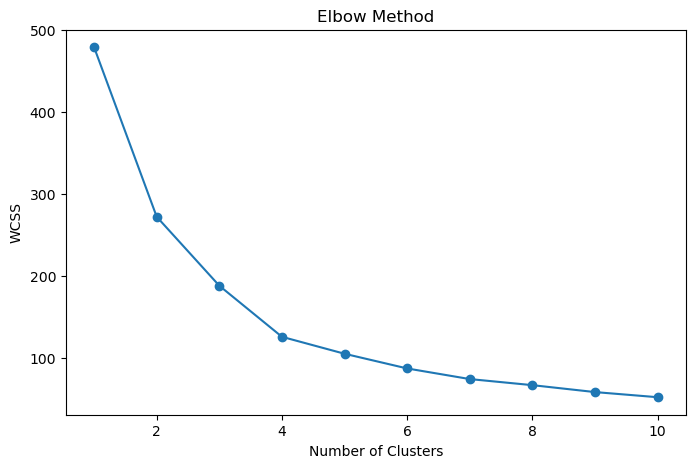

In [41]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [43]:
# when elbow grpah is not to clear, we can use Silhouette Score
for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_pca)

    score = silhouette_score(
        X_pca,
        labels
    )

    print(f"K={k}  Silhouette Score={score:.3f}")

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

K=2  Silhouette Score=0.401
K=3  Silhouette Score=0.389
K=4  Silhouette Score=0.416
K=5  Silhouette Score=0.388
K=6  Silhouette Score=0.394
K=7  Silhouette Score=0.381


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


K=8  Silhouette Score=0.364
K=9  Silhouette Score=0.366
K=10  Silhouette Score=0.383


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [44]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_pca)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [45]:
df["Cluster"] = clusters

In [46]:
df.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,19,15,39,1
1,1,21,15,81,0
2,0,20,16,6,1
3,0,23,16,77,0
4,0,31,17,40,1


### Visualize cluster

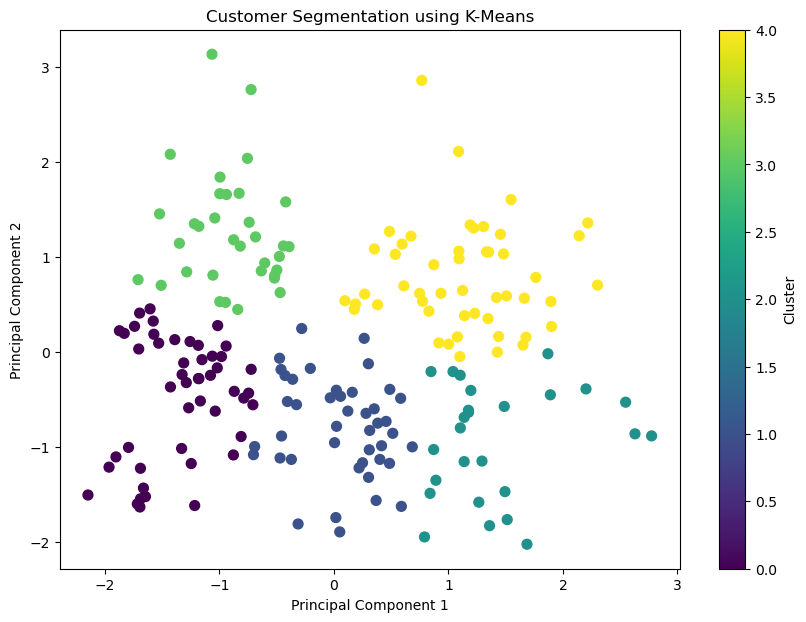

In [47]:
plt.figure(figsize=(10,7))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis",
    s=50
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

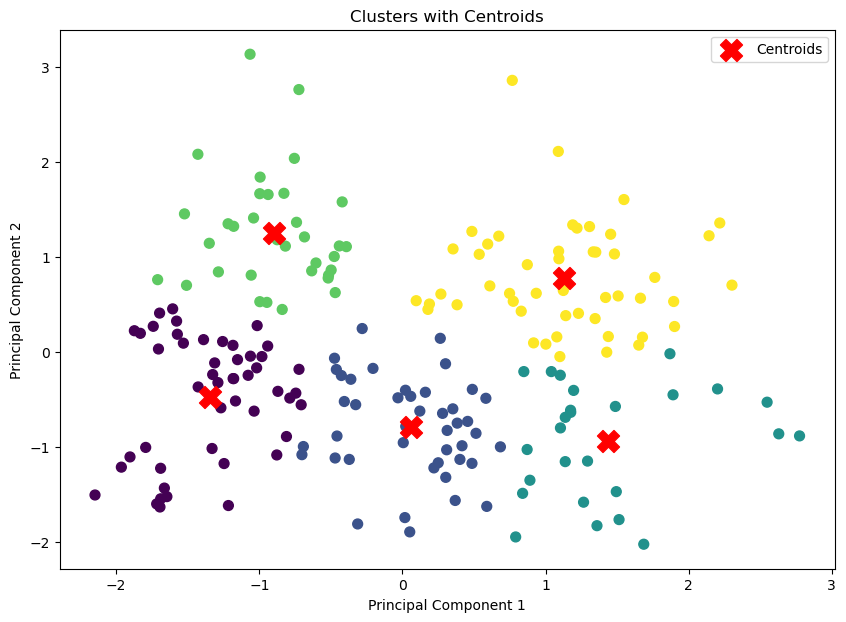

In [48]:
centers = kmeans.cluster_centers_

plt.figure(figsize=(10,7))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis",
    s=50
)

plt.scatter(
    centers[:,0],
    centers[:,1],
    c="red",
    s=250,
    marker="X",
    label="Centroids"
)

plt.title("Clusters with Centroids")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()

plt.show()

In [49]:
# Check the customer in each cluster
print(df["Cluster"].value_counts())

Cluster
4    49
0    48
1    43
3    34
2    26
Name: count, dtype: int64


In [51]:
cluster_summary = df.groupby("Cluster").mean().round().astype(int)

print(cluster_summary)

         Genre  Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                        
0            0   27                  50                      73
1            0   40                  50                      44
2            0   55                  44                      24
3            1   30                  82                      74
4            1   47                  75                      31


## Project Conclusion

In this project, we performed Customer Segmentation using the K-Means clustering algorithm. The dataset was first explored and preprocessed by encoding categorical values, removing unnecessary columns, and scaling the features. PCA was then applied to reduce the dataset to two dimensions for easier visualization. The optimal number of clusters was determined using the Elbow Method and confirmed with the Silhouette Score. Finally, K-Means grouped customers into different segments, and these clusters were analyzed to create meaningful business personas. These customer segments can help businesses design targeted marketing strategies and improve customer satisfaction.